# COMPEX
Clouds over cOMPlEX environment COMPEX ([blog](https://blog.uni-koeln.de/awares/category/campaigns-conf/compex/), [wiki](https://home.uni-leipzig.de/~ehrlich/COMPEX_wiki_doku/doku.php?id=start)) - Polar 5 campaign out of Longyearbyen (13.3.-15.4.2026).

### Detailed flight logs
| RF# | Date | Description | TO | TD | HH | Track (png) | Track (KML) |
|:---:|:----:|:------------|:--:|:--:|:--:|:-----------:|:-----------:|
| RF01 | 15.03.2026 | Investigate advected clouds over sea ice west of Svalbard. | 10:10 | 14:00 | 03:50 | [png](../img/COMPEX_P5_RF01_map.png) | [KML](../data/COMPEX_P5_RF01_track.kml) |
| RF02 | 16.03.2026 | Clouds over sea ice and ocean (south east of Svalbard) #1 | 9:17 | 13:33 | 04:16 | [png](../img/COMPEX_P5_RF02_map.png) | [KML](../data/COMPEX_P5_RF02_track.kml) |
| RF03 | 17.03.2026 | Statistics of clouds over sea ice. | 9:28 | 14:06 | 04:38 | [png](../img/COMPEX_P5_RF03_map.png) | [KML](../data/COMPEX_P5_RF03_track.kml) |
| RF04 | 19.03.2026 | Kongsfjorden survey to investigate sublimation processes. | 9:54 | 14:41 | 04:47 | [png](../img/COMPEX_P5_RF04_map.png) | [KML](../data/COMPEX_P5_RF04_track.kml) |
| RF05 | 24.03.2026 | Investigate the place of origin of an cold air outbreak | 9:55 | 14:14 | 04:16 | [png](../img/COMPEX_P5_RF05_map.png) | [KML](../data/COMPEX_P5_RF05_track.kml) |
| RF06 | 25.03.2026 | Ny-Alesund overflight, MPCs northwest of Svalbard and EarthCARE overpass | 12:17 | 16:55 | 04:48 | [png](../img/COMPEX_P5_RF06_map.png) | [KML](../data/COMPEX_P5_RF06_track.kml) |
| RF07 | 26.03.2026 | Capture developing cloud streets during CAOs using quasi-lagrangian approach | 09:58 | 13:47 | 03:49 | [png](../img/COMPEX_P5_RF07_map.png) | [KML](../data/COMPEX_P5_RF07_track.kml) |
| RF08 | 27.03.2026 | Radiation square, CAOs and EarthCARE overpass | 12:03 | 16:13 | 04:10 | [png](../img/COMPEX_P5_RF08_map.png) | [KML](../data/COMPEX_P5_RF08_track.kml) |
| RF09 | 30.03.2026 | Lagrangian sampling of WAI clouds (for Manfred) | 10:54 | 14:35 | 03:41 | [png](../img/COMPEX_P5_RF09_map.png) | [KML](../data/COMPEX_P5_RF09_track.kml) |
| RF10 | 31.03.2026 | Spatial variability of clouds over Kongsfjorden, convergence line NW of Svalbard | 08:00 | 13:02 | 05:02 | [png](../img/COMPEX_P5_RF10_map.png) | [KML](../data/COMPEX_P5_RF10_track.kml) |
| RF11 | 02.04.2026 | Lead experiment to measure profiles up- and downstream of lead #1 | 07:52 | 11:45 | 03:53 | [png](../img/COMPEX_P5_RF11_map.png) | [KML](../data/COMPEX_P5_RF11_track.kml) |
| RF12 | 04.04.2026 | Investigate the place of origin of an cold air outbreak along marginal sea ice zone | 07:47 | 12:20 | 04:33 | [png](../img/COMPEX_P5_RF12_map.png) | [KML](../data/COMPEX_P5_RF12_track.kml) |
| RF13 | 11.04.2026 | Spatial and temporal variability of clouds over Kongsfjorden with approaching front | 06:52 | 09:36 | 02:44 | [png](../img/COMPEX_P5_RF13_map.png) | [KML](../data/COMPEX_P5_RF13_track.kml) |
| RF14 | 13.04.2026 | Lead experiment to measure profiles up- and downstream of lead #2 | 07:50 | 12:03 | 04:13 | [png](../img/COMPEX_P5_RF14_map.png) | [KML](../data/COMPEX_P5_RF14_track.kml) |
| RF15 | 14.04.2026 | Clouds over sea ice and ocean (south east of Svalbard) #2 | 07:30 | 09:33 | 02:03 | [png](../img/COMPEX_P5_RF15_map.png) | [KML](../data/COMPEX_P5_RF15_track.kml) |

```{figure} ../img/compex_all_tracks.png
---
height: 400px
name: directive-fig
alt: COMPEX flight tracks
---
Flight tracks of the COMPEX campaign.
```


In [ ]:
%matplotlib inline
import ac3airborne
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
plt.style.use("../mplstyle/book")

# load intake catalog and flight segments
cat = ac3airborne.get_intake_catalog()
meta = ac3airborne.get_flight_segments()

ancillary = ['AMSR2_SIC']

def data_availability(mission, platform):
    """
    Plot data availability matrix
    """
    flights = list(filter(lambda d: meta[mission][platform][d]['mission'] == mission,  meta[mission][platform]))
    flights_dict = dict(filter(lambda d: mission == meta[mission][platform][d[0]]['mission'],  meta[mission][platform].items()))
    # store data availability in a matrix
    # data_availability = np.zeros(shape=(len(list(cat[mission][platform])),
    #                                     len(list(meta[mission][platform]))))
    data_availability = np.zeros(shape=(len(list(cat[mission][platform])),
                                        len(flights)))
    for i, dataset in enumerate(list(cat[mission][platform])):
        # data_availability[i, :] = np.isin(list(meta[mission][platform]), 
        #                                   list(cat[mission][platform][dataset]))
        data_availability[i, :] = np.isin(flights, 
                                          list(cat[mission][platform][dataset]))

    # plot data availability
    yscale = data_availability.shape[1]
    fig, ax = plt.subplots(1, 1, figsize=(5, 2+0.4*yscale))
    
    ax.pcolormesh(range(data_availability.shape[0]), 
                  range(data_availability.shape[1]), 
                  data_availability.T, 
                  shading='nearest',
                  vmin=0, 
                  vmax=1, 
                  cmap='RdYlGn', 
                  edgecolors='#eeeeee')

    ax.set_xticks(range(data_availability.shape[0]))
    ax.set_yticks(range(data_availability.shape[1]))

    xlabels = []
    for ds_name in list(cat[mission][platform]):
        if ds_name in ancillary:
            ds_name += '\n(ancillary)'
        xlabels.append(ds_name)

    ax.set_xticklabels(xlabels, rotation=90)
    # y_labels = [flight_id+', '+flight['date'].strftime('%Y-%m-%d') 
    #             for flight_id, flight in meta[mission][platform].items()]
    y_labels = [flight_id+', '+flight['date'].strftime('%Y-%m-%d') 
                for flight_id, flight in flights_dict.items()]
    ax.set_yticklabels(y_labels)

    ax.tick_params(labeltop=True)
    ax.invert_yaxis()

    available = mpatches.Patch(color='green', label='Data available')
    not_flown = mpatches.Patch(color='red', label='Data missing or\ninstrument failed')

    ax.legend(handles=[available, not_flown], ncol=1,
              bbox_to_anchor=(0, 1.01), loc='lower right')

    plt.show()

## Polar 5

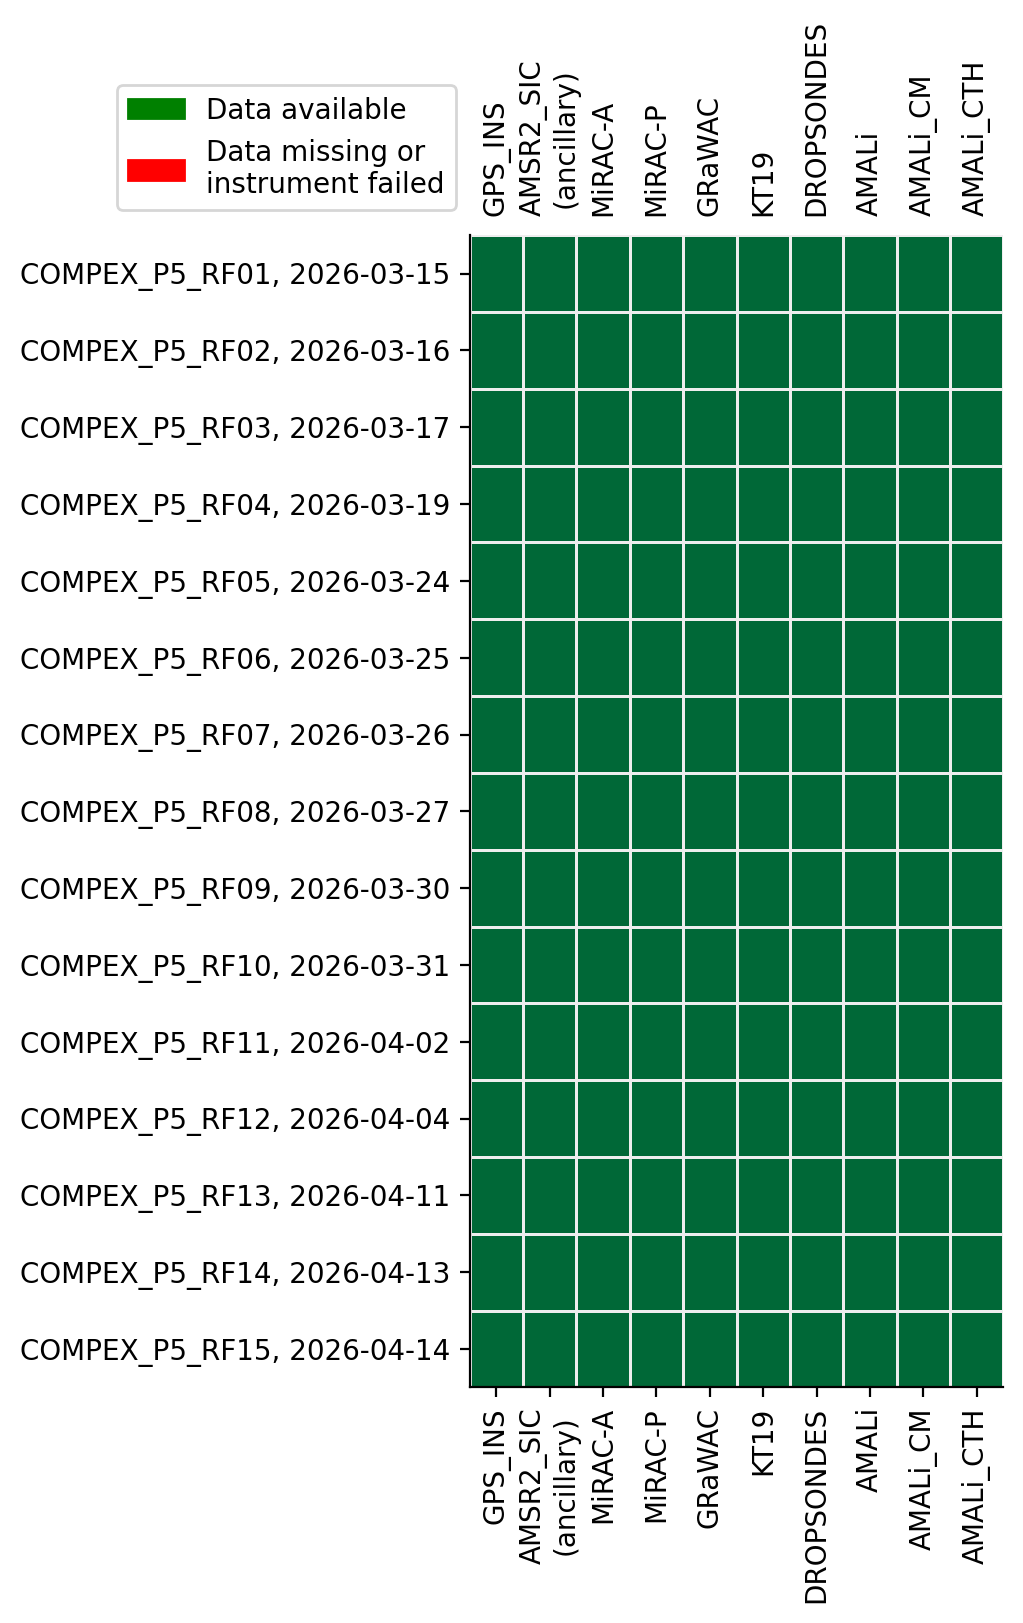

In [3]:
data_availability(mission='COMPEX', platform='P5')